In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge

import statsmodels.api as sm

In [21]:
data_path = os.path.abspath(os.path.join(os.path.abspath(os.curdir), os.pardir) + "\\data\\response_retail\\")
data_path

'C:\\git\\ML-hands-on-notebooks\\data\\response_retail'

In [23]:
df = pd.read_csv(
    data_path + "\\fashion_retail_campaign_response_model.csv",
    parse_dates=["date"]
)

print(df.shape)
df.head()

(4380, 43)


,date,campaign_id,campaign_name,channel,platform,audience_type,campaign_type,spend,impressions,clicks,...,adstock_14d,creative_fatigue,campaign_saturation,day_of_week,month,week,quarter,holiday_flag,incremental_revenue_proxy,marginal_roas_proxy
0,2025-08-01,C001,Summer Collection Launch,Paid Social,Meta,Prospecting,New Collection,4358.82,409218.202917,4554.0,...,4358.82,1.000000,0.982644,Friday,8,31,3,0,113548.12,26.05
1,2025-08-02,C001,Summer Collection Launch,Paid Social,Meta,Prospecting,New Collection,3686.12,390763.956042,4262.0,...,7609.06,1.023613,0.962993,Saturday,8,31,3,0,123901.40,33.61
2,2025-08-03,C001,Summer Collection Launch,Paid Social,Meta,Prospecting,New Collection,3321.54,297295.834718,3029.0,...,10169.69,1.230287,0.950785,Sunday,8,31,3,0,87882.01,26.46
3,2025-08-04,C001,Summer Collection Launch,Paid Social,Meta,Prospecting,New Collection,4612.09,797272.387575,7243.0,...,13764.82,0.594072,0.989265,Monday,8,32,3,0,207213.38,44.93
4,2025-08-05,C001,Summer Collection Launch,Paid Social,Meta,Prospecting,New Collection,4757.25,609007.734993,5195.0,...,17145.59,0.822176,0.992898,Tuesday,8,32,3,0,146156.24,30.72


In [25]:
df[
        ["campaign_id", "campaign_name", "channel", "platform",
         "audience_type", "campaign_type"]
    ].drop_duplicates()

,campaign_id,campaign_name,channel,platform,audience_type,campaign_type
0,C001,Summer Collection Launch,Paid Social,Meta,Prospecting,New Collection
365,C002,Denim Performance,Paid Search,Google,High Intent,Performance
730,C003,New Customer Acquisition,Paid Social,Instagram,Prospecting,Acquisition
1095,C004,Retargeting 7D,Paid Social,Meta,Retargeting,Conversion
1460,C005,Retargeting 30D,Paid Social,Meta,Retargeting,Conversion
1825,C006,Creator / Influencer,Video,YouTube,Prospecting,Awareness
2190,C007,Festive Collection,Paid Social,Meta,Prospecting,Seasonal
2555,C008,Clearance / Markdown,Paid Search,Google,High Intent,Promotion
2920,C009,Premium Collection,Paid Social,Instagram,Prospecting,Premium
3285,C010,Cart Abandonment,CRM,Email,Retention,Conversion


In [27]:
campaign_summary = (
    df.groupby(
        [
            "campaign_id",
            "campaign_name",
            "channel",
            "platform",
            "campaign_type"
        ]
    )
    .agg(
        spend=("spend", "sum"),
        revenue=("net_revenue", "sum"),
        orders=("orders", "sum"),
        customers=("new_customers", "sum"),
        contribution_margin=("contribution_margin", "sum"),
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum")
    )
    .reset_index()
)

campaign_summary

,campaign_id,campaign_name,channel,platform,campaign_type,spend,revenue,orders,customers,contribution_margin,impressions,clicks
0,C001,Summer Collection Launch,Paid Social,Meta,New Collection,1478623.86,8.583408e+07,897377,492594,4.623104e+07,1.806707e+08,1828306.0
1,C002,Denim Performance,Paid Search,Google,Performance,1266709.38,1.752631e+08,1829851,549043,9.610393e+07,1.575256e+08,4071979.0
2,C003,New Customer Acquisition,Paid Social,Instagram,Acquisition,1745718.20,8.061314e+07,840927,461477,4.305985e+07,2.162278e+08,1728407.0
3,C004,Retargeting 7D,Paid Social,Meta,Conversion,774438.31,1.384962e+08,1446496,434501,7.618088e+07,9.514955e+07,3043571.0
4,C005,Retargeting 30D,Paid Social,Meta,Conversion,639039.60,6.780000e+07,709119,212407,3.703514e+07,7.898377e+07,1559455.0
5,C006,Creator / Influencer,Video,YouTube,Awareness,1049007.02,3.169179e+07,331435,183107,1.656621e+07,1.291645e+08,768608.0
6,C007,Festive Collection,Paid Social,Meta,Seasonal,2281441.90,1.694820e+08,1774422,972572,9.182458e+07,2.857578e+08,3462365.0
7,C008,Clearance / Markdown,Paid Search,Google,Promotion,1487152.91,1.970914e+08,2495430,751059,1.079676e+08,1.790556e+08,5362206.0
8,C009,Premium Collection,Paid Social,Instagram,Premium,1132007.92,5.373619e+07,560268,308419,2.873726e+07,1.396392e+08,1255817.0
9,C010,Cart Abandonment,CRM,Email,Conversion,318140.24,8.892317e+07,930869,276716,4.909871e+07,3.860393e+07,2143758.0


In [29]:
campaign_summary["ROAS"] = (
    campaign_summary["revenue"] /
    campaign_summary["spend"]
)

campaign_summary["CPA"] = (
    campaign_summary["spend"] /
    campaign_summary["orders"].clip(lower=1)
)

campaign_summary["Profit_ROAS"] = (
    campaign_summary["contribution_margin"] /
    campaign_summary["spend"]
)

campaign_summary["CTR"] = (
    campaign_summary["clicks"] /
    campaign_summary["impressions"]
)

campaign_summary = campaign_summary.sort_values(
    "ROAS",
    ascending=False
)

campaign_summary

,campaign_id,campaign_name,channel,platform,campaign_type,spend,revenue,orders,customers,contribution_margin,impressions,clicks,ROAS,CPA,Profit_ROAS,CTR
9,C010,Cart Abandonment,CRM,Email,Conversion,318140.24,8.892317e+07,930869,276716,4.909871e+07,3.860393e+07,2143758.0,279.509333,0.341767,154.330412,0.055532
3,C004,Retargeting 7D,Paid Social,Meta,Conversion,774438.31,1.384962e+08,1446496,434501,7.618088e+07,9.514955e+07,3043571.0,178.834438,0.535389,98.369206,0.031987
1,C002,Denim Performance,Paid Search,Google,Performance,1266709.38,1.752631e+08,1829851,549043,9.610393e+07,1.575256e+08,4071979.0,138.360977,0.692247,75.868963,0.025850
7,C008,Clearance / Markdown,Paid Search,Google,Promotion,1487152.91,1.970914e+08,2495430,751059,1.079676e+08,1.790556e+08,5362206.0,132.529377,0.595951,72.600207,0.029947
4,C005,Retargeting 30D,Paid Social,Meta,Conversion,639039.60,6.780000e+07,709119,212407,3.703514e+07,7.898377e+07,1559455.0,106.096718,0.901174,57.954373,0.019744
11,C012,Flash Sale,Paid Social,Meta,Promotion,2544997.13,1.937116e+08,2454386,738653,1.050176e+08,3.202008e+08,4477216.0,76.114663,1.036918,41.264318,0.013983
6,C007,Festive Collection,Paid Social,Meta,Seasonal,2281441.90,1.694820e+08,1774422,972572,9.182458e+07,2.857578e+08,3462365.0,74.287247,1.285738,40.248486,0.012116
0,C001,Summer Collection Launch,Paid Social,Meta,New Collection,1478623.86,8.583408e+07,897377,492594,4.623104e+07,1.806707e+08,1828306.0,58.049978,1.647718,31.266260,0.010120
8,C009,Premium Collection,Paid Social,Instagram,Premium,1132007.92,5.373619e+07,560268,308419,2.873726e+07,1.396392e+08,1255817.0,47.469802,2.020476,25.386098,0.008993
2,C003,New Customer Acquisition,Paid Social,Instagram,Acquisition,1745718.20,8.061314e+07,840927,461477,4.305985e+07,2.162278e+08,1728407.0,46.177637,2.075945,24.665978,0.007993


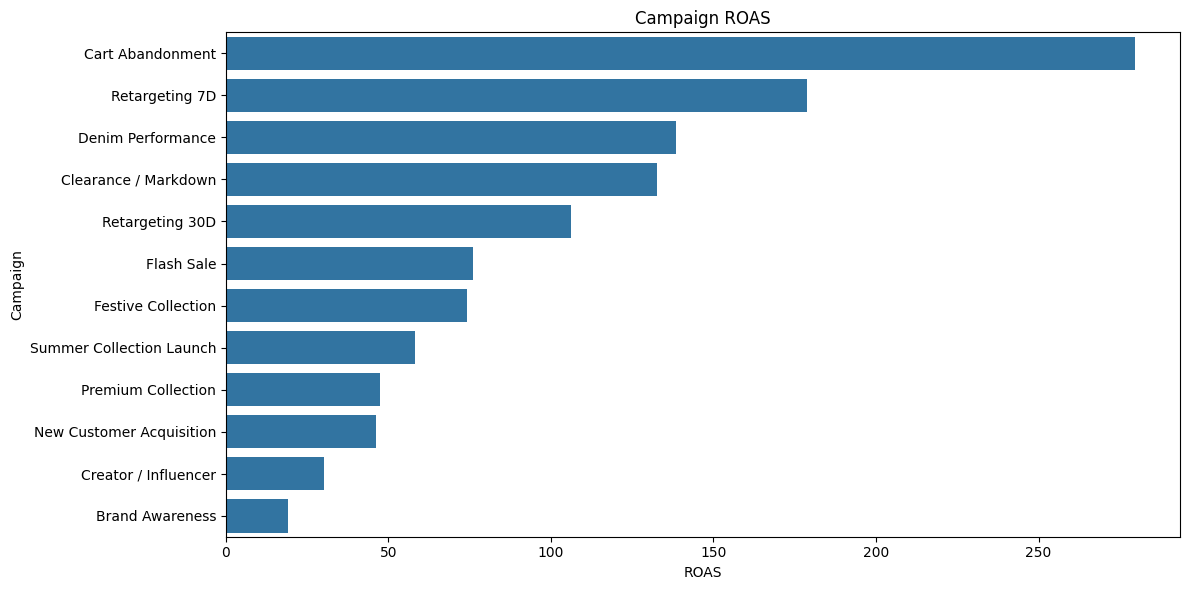

In [30]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=campaign_summary,
    x="ROAS",
    y="campaign_name"
)

plt.title("Campaign ROAS")
plt.xlabel("ROAS")
plt.ylabel("Campaign")

plt.tight_layout()
plt.show()

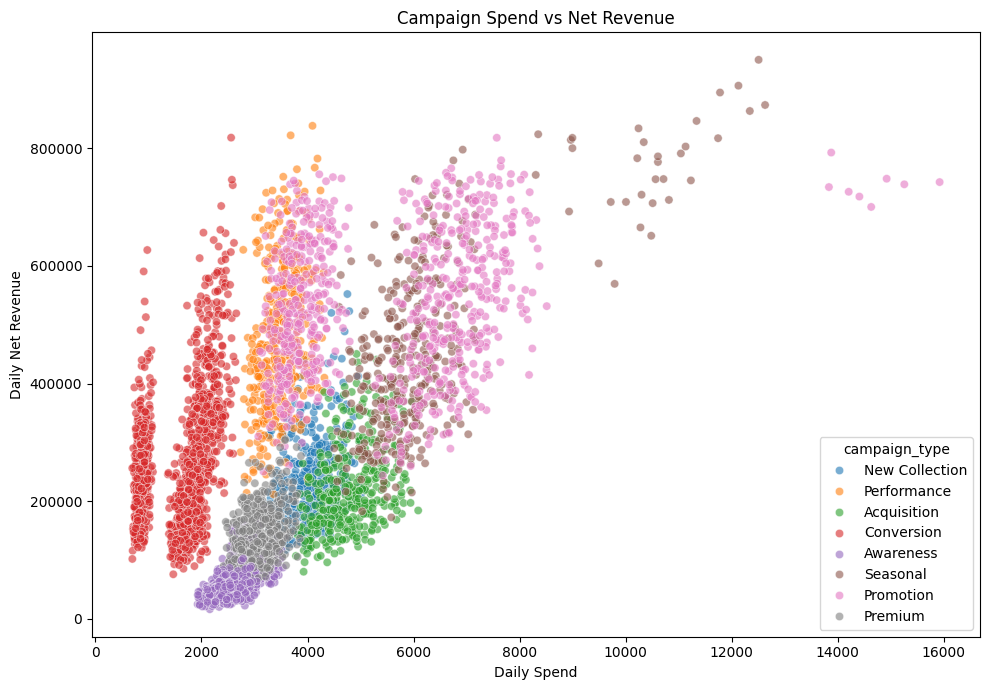

In [31]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="spend",
    y="net_revenue",
    hue="campaign_type",
    alpha=0.6
)

plt.title("Campaign Spend vs Net Revenue")
plt.xlabel("Daily Spend")
plt.ylabel("Daily Net Revenue")

plt.tight_layout()
plt.show()